This is part 2 of the project: **Feature engineering**

Interaction terms, composite score, exp_per_age — add signals before training

# Summary from part 1

This is the summary from part 1 in previous notebook

In [1]:
import glob
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



# ── Step 1: load & inspect ────────────────────────────────────────────────────
df_fn = glob.glob("*recruitment_data*")
df = pd.read_csv(df_fn[0])

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

# ── Step 2: define features — drop leaky HiringDecision ──────────────────────
FEATURES = [
    'Age', 'Gender', 'EducationLevel', 'ExperienceYears',
    'PreviousCompanies', 'DistanceFromCompany',
    'InterviewScore', 'SkillScore', 'PersonalityScore'
]
X = df[FEATURES].copy()

# ── Step 3: encode target ─────────────────────────────────────────────────────
strategy_map = {
    1: 0, 2: 1, 3: 2,
    'Aggressive': 0, 'Moderate': 1, 'Conservative': 2
}
y = df['RecruitmentStrategy'].map(strategy_map)
class_names = ['Aggressive', 'Moderate', 'Conservative']

assert y.isnull().sum() == 0, f"Unmapped values: {df['RecruitmentStrategy'][y.isnull()].unique()}"
assert set(y.unique()) == {0, 1, 2}

# ── Step 4: encode features ───────────────────────────────────────────────────
# Gender is already encoded: Male=0, Female=1 (per Kaggle description)
# No transformation needed — just document it
GENDER_MAP = {0: 'Male', 1: 'Female'}

# Only create label column for plots — never use for training
X['Gender_label'] = X['Gender'].map(GENDER_MAP)
X = X.drop(columns=['Gender_label'])  # drop after inspection

# EducationLevel is ordinal 1–4 — treat as numeric, no encoding needed
# All other features are already numeric

assert X.select_dtypes('object').empty, "String columns remain!"

# ── Step 5: check class balance ───────────────────────────────────────────────
counts = y.value_counts().sort_index()
pcts   = y.value_counts(normalize=True).sort_index() * 100
ratio  = counts.max() / counts.min()

print("\n=== Class distribution ===")
for i, name in enumerate(class_names):
    print(f"  {name:<15} {counts[i]:>4} rows  ({pcts[i]:.1f}%)")
print(f"\nImbalance ratio: {ratio:.2f}x")
print("→ Mild imbalance: use F1-macro + class_weight='balanced'")

# ── Step 6: split first, then scale ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
for split_name, y_split in [('Train', y_train), ('Test', y_test)]:
    counts_s = y_split.value_counts().sort_index()
    pcts_s   = y_split.value_counts(normalize=True).sort_index() * 100
    print(f"\n{split_name}:")
    for i, name in enumerate(class_names):
        print(f"  {name:<15} {counts_s[i]:>4} rows  ({pcts_s[i]:.1f}%)")

# ── Step 7: scale ─────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)  # fit on train only
X_test_s  = scaler.transform(X_test)       # apply train stats to test

# ── Step 8: verify ────────────────────────────────────────────────────────────
print("\n=== Check 1: train means (≈0) and stds (≈1) ===")
train_check = pd.DataFrame({
    'feature': X_train.columns,
    'mean':    X_train_s.mean(axis=0).round(3),
    'std':     X_train_s.std(axis=0).round(3),
})
print(train_check.to_string(index=False))

print("\n=== Check 2: test means (small offset fine) ===")
test_check = pd.DataFrame({
    'feature':        X_train.columns,
    'train_mean_was': scaler.mean_.round(3),
    'test_mean_now':  X_test_s.mean(axis=0).round(3),
})
print(test_check.to_string(index=False))

print("\n=== Check 3: NaN check ===")
assert np.isnan(X_train_s).sum() == 0, "NaNs in X_train_s!"
assert np.isnan(X_test_s).sum()  == 0, "NaNs in X_test_s!"
print("All checks passed. Ready for feature engineering.")

(1500, 11)
Age                      int64
Gender                   int64
EducationLevel           int64
ExperienceYears          int64
PreviousCompanies        int64
DistanceFromCompany    float64
InterviewScore           int64
SkillScore               int64
PersonalityScore         int64
RecruitmentStrategy      int64
HiringDecision           int64
dtype: object
Age                    0
Gender                 0
EducationLevel         0
ExperienceYears        0
PreviousCompanies      0
DistanceFromCompany    0
InterviewScore         0
SkillScore             0
PersonalityScore       0
RecruitmentStrategy    0
HiringDecision         0
dtype: int64

=== Class distribution ===
  Aggressive       445 rows  (29.7%)
  Moderate         770 rows  (51.3%)
  Conservative     285 rows  (19.0%)

Imbalance ratio: 2.70x
→ Mild imbalance: use F1-macro + class_weight='balanced'

Train: 1200 rows | Test: 300 rows

Train:
  Aggressive       356 rows  (29.7%)
  Moderate         616 rows  (51.3%)
  Conserv

# Why feature engineering before training

**Purpose**: 
- In this context, **feature engineering** means considering the **interaction between features**
- Raw features describe each candidate attribute in isolation. But a recruiter's strategy is rarely driven by one thing — it's driven by combinations.
    - Example: a high SkillScore matters differently for a fresh graduate vs a 10-year veteran. Feature engineering lets you encode those combinations explicitly.


| Raw feature                     | What it misses                          | Engineered feature            |
|--------------------------------|----------------------------------------|------------------------------|
| InterviewScore                 | ignores SkillScore context             | composite_score (weighted blend) |
| ExperienceYears                | ignores candidate's age                | exp_per_age (career density) |
| DistanceFromCompany            | ignores seniority                      | distance_x_exp (senior tolerance) |
| SkillScore + InterviewScore    | treated independently                  | skill_interview_gap (consistency) |
| EducationLevel                 | ignores experience                     | edu_x_exp (qualification density) |

Tree models (`RF`, `XGBoost`) can discover interactions on their own — but only if the signal is strong enough. Explicitly engineering the interaction gives them a head start and often improves performance even for tree-based models.

# Composite_score — weighted candidate quality

Recruiters rarely look at `InterviewScore`, `SkillScore`, and `PersonalityScore` in isolation — they form a mental average. This feature encodes that blend explicitly, weighted toward the more objective scores.

In [25]:
# Hypothesis: Aggressive recruiters chase high composite candidates
# Conservative recruiters may accept lower composites

# Weights: Interview + Skill matter more than Personality
X_train['composite_score'] = (
    X_train['InterviewScore']   * 0.4 +
    X_train['SkillScore']        * 0.4 +
    X_train['PersonalityScore']  * 0.2
)
X_test['composite_score'] = (
    X_test['InterviewScore']    * 0.4 +
    X_test['SkillScore']         * 0.4 +
    X_test['PersonalityScore']   * 0.2
)

# Check the range looks sensible
print(X_train['composite_score'].describe().round(2))

count    1200.00
mean       50.48
std        17.09
min         1.80
25%        38.95
50%        51.00
75%        63.00
max        93.40
Name: composite_score, dtype: float64


The weights (0.4, 0.4, 0.2) are a hypothesis — not gospel. After training, check SHAP values. If composite_score has high importance, the weights were useful. You can also try equal weights (0.33 each) and compare CV scores.

In [22]:
# Check composite_score correlations
print("=== composite_score correlations ===")
corr_composite = X_train[['InterviewScore', 'SkillScore',
                           'PersonalityScore', 'composite_score']].corr().round(3)
print(corr_composite)

=== composite_score correlations ===
                  InterviewScore  SkillScore  PersonalityScore  \
InterviewScore             1.000      -0.004            -0.028   
SkillScore                -0.004       1.000            -0.016   
PersonalityScore          -0.028      -0.016             1.000   
composite_score            0.647       0.678             0.316   

                  composite_score  
InterviewScore              0.647  
SkillScore                  0.678  
PersonalityScore            0.316  
composite_score             1.000  


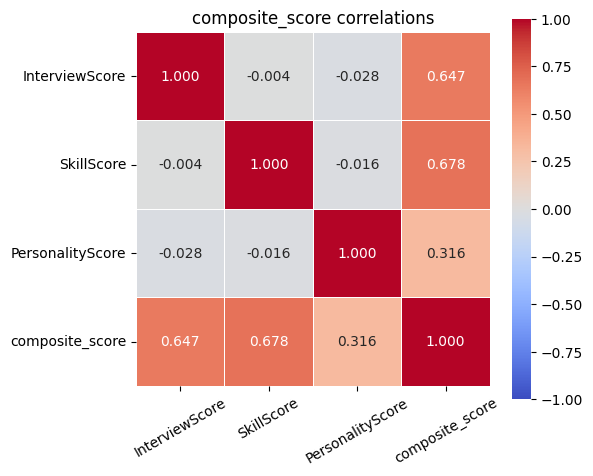

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_composite = X_train[['InterviewScore', 'SkillScore',
                           'PersonalityScore', 'composite_score']].corr().round(3)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr_composite,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('composite_score correlations')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

| Pair                                      | Correlation | Verdict                                      |
|------------------------------------------|-------------|----------------------------------------------|
| `composite_score` vs `InterviewScore`        | 0.647       | related but not redundant                    |
| `composite_score` vs `SkillScore`           | 0.678       | related but not redundant                    |
| `composite_score` vs `PersonalityScore`      | 0.316       | weakly related — expected since weight is 0.2|
| `InterviewScore` vs `SkillScore`             | -0.004      | essentially zero — independent of each other |
| `InterviewScore` vs `PersonalityScore`       | -0.028      | essentially zero                             |
| `SkillScore` vs `PersonalityScore`           | -0.016      | essentially zero                             |

**Key takeaways:**

The three raw scores (`InterviewScore`, `SkillScore`, `PersonalityScore`) are almost completely uncorrelated with each other — near zero across the board. This means they're measuring genuinely independent things, which is actually good news.

- `composite_score` sits at 0.647 and 0.678 with its two major components — well within the "related but not redundant" zone. It's not just copying `InterviewScore` or `SkillScore`. The 0.316 with `PersonalityScore` reflects its smaller weight (0.2) correctly.
- Nothing here is above 0.95, so there's **no multicollinearity concern**. The composite genuinely summarises all three scores into one signal that none of the three captures alone.

In [26]:
# Example: Your composite_score numbers
r_interview = 0.647
r_skill     = 0.678

print(f"Shared variance with InterviewScore: {r_interview**2:.1%}")
print(f"Shared variance with SkillScore:     {r_skill**2:.1%}")
print(f"Unique variance in composite_score:  ~{1 - max(r_interview, r_skill)**2:.1%}")

# Output:
# Shared variance with InterviewScore: 41.9%
# Shared variance with SkillScore:     46.0%
# Unique variance in composite_score:  ~54.0%

Shared variance with InterviewScore: 41.9%
Shared variance with SkillScore:     46.0%
Unique variance in composite_score:  ~54.0%


54% of what `composite_score` carries is not explained by either raw score alone — that's the new signal your model gets by having it as a feature. Anything above ~10% unique variance is generally worth keeping.

# distance_x_exp — senior candidates and commute tolerance

Assuming these jobs are in-person, in-office or hybrid job and not a remote job. A recruiter using Aggressive strategy might pursue a highly experienced candidate even if they live far away — worth the effort. For Conservative strategy, distance might be a dealbreaker. This interaction captures that logic.

Multiplication-based interactions are the simplest form. High × high = very high signal. Low × anything = low. It only fires when both distance AND experience are high simultaneously.

In [5]:
# Senior + far away → Aggressive recruiter might still pursue them
# Junior + far away → Conservative recruiter probably won't bother

X_train['distance_x_exp'] = (
    X_train['DistanceFromCompany'] * X_train['ExperienceYears']
)
X_test['distance_x_exp'] = (
    X_test['DistanceFromCompany'] * X_test['ExperienceYears']
)

print(X_train['distance_x_exp'].describe().round(2))

count    1200.00
mean      199.10
std       178.27
min         0.00
25%        49.13
50%       149.01
75%       313.95
max       764.60
Name: distance_x_exp, dtype: float64


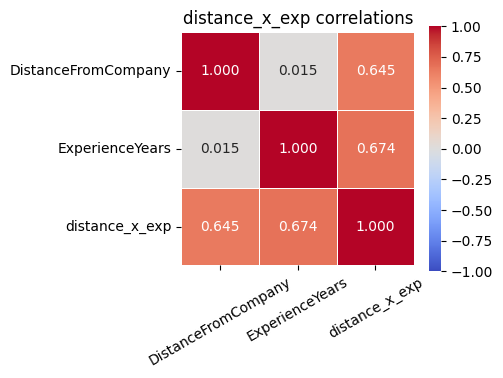

In [27]:
corr_distance = X_train[['DistanceFromCompany', 'ExperienceYears',
                          'distance_x_exp']].corr().round(3)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    corr_distance,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('distance_x_exp correlations')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

**What this tells you**

The two parent features (`DistanceFromCompany` and `ExperienceYears`) are almost completely independent of each other at r=0.015. This is actually the ideal condition for a multiplication interaction feature — when two independent things are multiplied together, the result captures something genuinely new that neither parent carries alone.

`distance_x_exp` sits at 0.645 and 0.674 with its parents — almost identical pattern to `composite_score`. Shared variance with each parent:


In [28]:
print(f"Shared variance with DistanceFromCompany: {0.645**2:.1%}")  # 41.6%
print(f"Shared variance with ExperienceYears:     {0.674**2:.1%}")  # 45.4%
print(f"Unique variance in distance_x_exp:        ~{1 - 0.674**2:.1%}")  # ~54.6%


Shared variance with DistanceFromCompany: 41.6%
Shared variance with ExperienceYears:     45.4%
Unique variance in distance_x_exp:        ~54.6%


About 55% of what `distance_x_exp` carries is not explained by either parent alone — same story as `composite_score`.

# skill_interview_gap — consistency check

A candidate who scores 90 on `SkillScore` but only 50 on `InterviewScore` is inconsistent — great on paper, poor in person. A `Conservative` recruiter might avoid that risk. The gap between scores captures this inconsistency.

In [10]:
df['skill_interview_gap'] = df['SkillScore'] - df['InterviewScore']

- gap > 0  →  SkillScore > InterviewScore  →  stronger on paper than in person
- gap = 0  →  perfectly consistent candidate
- gap < 0  →  InterviewScore > SkillScore  →  stronger in person than on paper

Why this might matter for RecruitmentStrategy
The hypothesis is that different recruitment strategies tolerate inconsistency differently:

- `Aggressive` recruiters chase top talent and might be willing to overlook a nervous interviewee if their skill score is exceptional. They might actually favour candidates with large positive gaps — high skill, underperformed in interview.
- `Conservative` recruiters prefer safe, predictable hires. A candidate who interviews brilliantly but has weak underlying skills (negative gap) is a risk. They'd prefer near-zero gaps — what you see is what you get.
- `Moderate` sits in between.

#### The four candidate archetypes it reveals

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Four example candidates
candidates = {
    'High skill,\nweak interview':  {'SkillScore': 88, 'InterviewScore': 52},
    'Consistent\nhigh performer':   {'SkillScore': 85, 'InterviewScore': 83},
    'Consistent\nlow performer':    {'SkillScore': 42, 'InterviewScore': 45},
    'Charming,\nweak skills':       {'SkillScore': 48, 'InterviewScore': 84},
}

for name, scores in candidates.items():
    gap = scores['SkillScore'] - scores['InterviewScore']
    print(f"{name.replace(chr(10),' '):<30} gap = {gap:+.0f}")

# Output:
# High skill, weak interview       gap = +36  ← nervous expert
# Consistent high performer        gap = +2   ← ideal candidate
# Consistent low performer         gap = -3   ← consistent but weak
# Charming, weak skills            gap = -36  ← interview performer

High skill, weak interview     gap = +36
Consistent high performer      gap = +2
Consistent low performer       gap = -3
Charming, weak skills          gap = -36


#### Check whether the gap actually differs across strategies

=== Mean skill_interview_gap by strategy ===
                mean    std  min  max
strategy_label                       
Aggressive      1.11  42.53  -91   96
Conservative   -3.14  41.29  -97   99
Moderate        1.59  40.16  -94   98


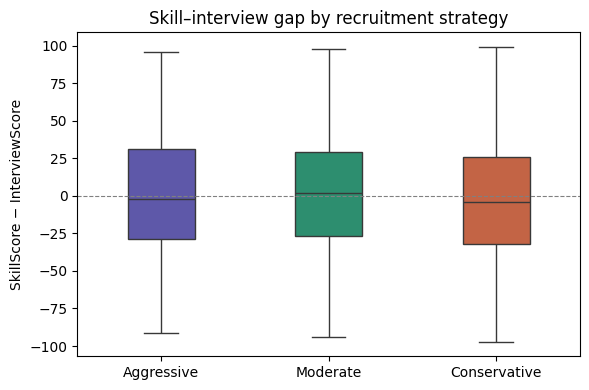

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add gap to the full dataframe temporarily for EDA
df['skill_interview_gap'] = df['SkillScore'] - df['InterviewScore']
df['strategy_label'] = df['RecruitmentStrategy'].map({
    1: 'Aggressive', 2: 'Moderate', 3: 'Conservative'
})

# Mean gap per strategy
print("=== Mean skill_interview_gap by strategy ===")
print(df.groupby('strategy_label')['skill_interview_gap'].agg(['mean','std','min','max']).round(2))

# Box plot — does the distribution differ across strategies?
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(
    data=df,
    x='strategy_label',
    y='skill_interview_gap',
    hue='strategy_label',
    order=['Aggressive', 'Moderate', 'Conservative'],
    palette={
        'Aggressive':   '#534AB7',
        'Moderate':     '#1D9E75',
        'Conservative': '#D85A30'
    },
    width=0.4,
    legend=False,
    ax=ax
)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('')
ax.set_ylabel('SkillScore − InterviewScore')
ax.set_title('Skill–interview gap by recruitment strategy')
plt.tight_layout()
plt.show()

                     SkillScore  InterviewScore  skill_interview_gap
SkillScore                1.000          -0.005                0.718
InterviewScore           -0.005           1.000               -0.700
skill_interview_gap       0.718          -0.700                1.000


The mean gap is essentially zero for all three strategies. The tiny differences (1.11 vs 1.59 vs -3.14) are completely swamped by standard deviations of ~41 points. That means the distributions overlap almost entirely — which the box plot confirms. All three boxes sit right on the dashed zero line with nearly identical spreads.

**What the box plot confirms**
All three boxes:

- Have their median sitting right at or very near zero
- Span roughly the same range (about -30 to +30 for the IQR)
- Have whiskers stretching almost identically from -100 to +100

**There is no visible separation between `Aggressive`, `Moderate`, and `Conservative`.** A model trained on this feature would learn essentially the same thing from all three classes — which means it learns nothing useful about the target.
--> DROPPING THIS FEATURE

# Final stretch - applying interaction features to the dataset

In [15]:
def add_features(df):
    df = df.copy()

    # 1. Weighted composite quality score
    df['composite_score'] = (
        df['InterviewScore']  * 0.4 +
        df['SkillScore']       * 0.4 +
        df['PersonalityScore'] * 0.2
    )
    # 2. Senior candidate × distance interaction
    df['distance_x_exp'] = (
        df['DistanceFromCompany'] * df['ExperienceYears']
    )
    return df

In [16]:
X_train = add_features(X_train)
X_test  = add_features(X_test)

print(f"Total features: {X_train.shape[1]}")
# → 11 features (9 original + 2 engineered)

assert X_train.isnull().sum().sum() == 0
assert X_test.isnull().sum().sum()  == 0
print("Done. Re-run scaling next.")

Total features: 11
Done. Re-run scaling next.


In [21]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Scaled shape: {X_train_s.shape}")
# → (1200, 11)

Scaled shape: (1200, 11)


**Features we are going to train with**

| #  | Feature             | Type        | Status |
|----|---------------------|-------------|--------|
| 1  | Age                 | original    | keep   |
| 2  | Gender              | original    | keep   |
| 3  | EducationLevel      | original    | keep   |
| 4  | ExperienceYears     | original    | keep   |
| 5  | PreviousCompanies   | original    | keep   |
| 6  | DistanceFromCompany | original    | keep   |
| 7  | InterviewScore      | original    | keep   |
| 8  | SkillScore          | original    | keep   |
| 9  | PersonalityScore    | original    | keep   |
| 10 | composite_score     | engineered  | keep   |
| 11 | distance_x_exp      | engineered  | keep   |